In [1]:
# Modules
import pandas as pd
import requests
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# API URL and headers
api_url = "https://www.ngdc.noaa.gov/hazel/hazard-service/api/v1/volcanoes"
headers = {
    'accept': '*/*'
}

In [3]:
response = requests.get(api_url, headers = headers)
json = response.json()
items = json.get('items', [])
df = pd.DataFrame(items)
df.to_csv('volcanoes.csv', index = False)

In [4]:
df.shape

(200, 43)

In [5]:
df.columns

Index(['id', 'year', 'month', 'day', 'tsunamiEventId', 'earthquakeEventId',
       'volcanoLocationId', 'volcanoLocationNewNum', 'volcanoLocationNum',
       'name', 'location', 'country', 'latitude', 'longitude', 'elevation',
       'morphology', 'agent', 'deathsTotal', 'deathsAmountOrderTotal',
       'damageAmountOrderTotal', 'significant', 'publish', 'eruption',
       'status', 'timeErupt', 'vei', 'deathsAmountOrder', 'damageAmountOrder',
       'housesDestroyedAmountOrderTotal', 'deaths', 'injuries',
       'injuriesAmountOrder', 'injuriesTotal', 'injuriesAmountOrderTotal',
       'housesDestroyedAmountOrder', 'housesDestroyed', 'housesDestroyedTotal',
       'missingAmountOrder', 'missingAmountOrderTotal', 'missing',
       'missingTotal', 'damageMillionsDollars', 'damageMillionsDollarsTotal'],
      dtype='object')

In [6]:
new_df = df[['id', 'year', 'month', 'day', 'tsunamiEventId', 'earthquakeEventId', 'volcanoLocationId', 'volcanoLocationNewNum', 'name' , 'country', 'elevation', 'morphology', 'deathsTotal', 'vei', 'deaths']]
new_df

,id,year,month,day,tsunamiEventId,earthquakeEventId,volcanoLocationId,volcanoLocationNewNum,name,country,elevation,morphology,deathsTotal,vei,deaths
0,1,1169,2.0,4.0,2852.0,421.0,10106,211060,Etna,Italy,3357,Stratovolcano,16000.0,NaN,NaN
1,2,1329,7.0,NaN,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,NaN,1.0,NaN
2,3,1883,3.0,NaN,NaN,NaN,30301,233010,Karthala,Comoros,2361,Shield volcano,NaN,2.0,NaN
3,4,1888,3.0,13.0,1175.0,NaN,50107,251070,Ritter Island,Papua New Guinea,75,Stratovolcano,NaN,2.0,NaN
4,5,1850,NaN,NaN,NaN,NaN,50214,252140,Rabaul,Papua New Guinea,688,Pyroclastic shield,NaN,2.0,NaN
5,6,1832,11.0,1.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,NaN,2.0,NaN
6,7,1977,1.0,10.0,NaN,NaN,20303,223030,Nyiragongo,"Congo, DRC",3470,Stratovolcano,NaN,1.0,NaN
7,8,787,NaN,NaN,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,NaN,3.0,NaN
8,9,1779,8.0,8.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,NaN,2.0,NaN
9,10,1302,NaN,NaN,NaN,NaN,10103,211030,Ischia,Italy,789,Complex volcano,NaN,NaN,NaN


In [7]:
new_df = new_df.dropna(subset= ['year', 'month', 'day'])
new_df

,id,year,month,day,tsunamiEventId,earthquakeEventId,volcanoLocationId,volcanoLocationNewNum,name,country,elevation,morphology,deathsTotal,vei,deaths
0,1,1169,2.0,4.0,2852.0,421.0,10106,211060,Etna,Italy,3357,Stratovolcano,16000.0,NaN,NaN
3,4,1888,3.0,13.0,1175.0,NaN,50107,251070,Ritter Island,Papua New Guinea,75,Stratovolcano,NaN,2.0,NaN
5,6,1832,11.0,1.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,NaN,2.0,NaN
6,7,1977,1.0,10.0,NaN,NaN,20303,223030,Nyiragongo,"Congo, DRC",3470,Stratovolcano,NaN,1.0,NaN
8,9,1779,8.0,8.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,NaN,2.0,NaN
10,11,1907,8.0,4.0,NaN,NaN,201112,221112,Alayta,Ethiopia,1496,Shield volcano,NaN,2.0,NaN
11,12,1905,3.0,10.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,1.0,2.0,1.0
12,13,1986,7.0,24.0,NaN,NaN,10104,211040,Stromboli,Italy,924,Stratovolcano,1.0,2.0,1.0
13,14,1536,3.0,23.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,1.0,3.0,1.0
14,15,1904,2.0,25.0,NaN,NaN,30301,233010,Karthala,Comoros,2361,Shield volcano,1.0,2.0,1.0


In [8]:
new_df.index = range(1, len(new_df) + 1)
new_df

,id,year,month,day,tsunamiEventId,earthquakeEventId,volcanoLocationId,volcanoLocationNewNum,name,country,elevation,morphology,deathsTotal,vei,deaths
1,1,1169,2.0,4.0,2852.0,421.0,10106,211060,Etna,Italy,3357,Stratovolcano,16000.0,NaN,NaN
2,4,1888,3.0,13.0,1175.0,NaN,50107,251070,Ritter Island,Papua New Guinea,75,Stratovolcano,NaN,2.0,NaN
3,6,1832,11.0,1.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,NaN,2.0,NaN
4,7,1977,1.0,10.0,NaN,NaN,20303,223030,Nyiragongo,"Congo, DRC",3470,Stratovolcano,NaN,1.0,NaN
5,9,1779,8.0,8.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,NaN,2.0,NaN
6,11,1907,8.0,4.0,NaN,NaN,201112,221112,Alayta,Ethiopia,1496,Shield volcano,NaN,2.0,NaN
7,12,1905,3.0,10.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,1.0,2.0,1.0
8,13,1986,7.0,24.0,NaN,NaN,10104,211040,Stromboli,Italy,924,Stratovolcano,1.0,2.0,1.0
9,14,1536,3.0,23.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,1.0,3.0,1.0
10,15,1904,2.0,25.0,NaN,NaN,30301,233010,Karthala,Comoros,2361,Shield volcano,1.0,2.0,1.0


In [9]:
new_df = new_df.assign(totalDeaths = new_df[['deaths','deathsTotal']].max())
new_df

,id,year,month,day,tsunamiEventId,earthquakeEventId,volcanoLocationId,volcanoLocationNewNum,name,country,elevation,morphology,deathsTotal,vei,deaths,totalDeaths
1,1,1169,2.0,4.0,2852.0,421.0,10106,211060,Etna,Italy,3357,Stratovolcano,16000.0,NaN,NaN,NaN
2,4,1888,3.0,13.0,1175.0,NaN,50107,251070,Ritter Island,Papua New Guinea,75,Stratovolcano,NaN,2.0,NaN,NaN
3,6,1832,11.0,1.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,NaN,2.0,NaN,NaN
4,7,1977,1.0,10.0,NaN,NaN,20303,223030,Nyiragongo,"Congo, DRC",3470,Stratovolcano,NaN,1.0,NaN,NaN
5,9,1779,8.0,8.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,NaN,2.0,NaN,NaN
6,11,1907,8.0,4.0,NaN,NaN,201112,221112,Alayta,Ethiopia,1496,Shield volcano,NaN,2.0,NaN,NaN
7,12,1905,3.0,10.0,NaN,NaN,10102,211020,Vesuvius,Italy,1281,Complex volcano,1.0,2.0,1.0,NaN
8,13,1986,7.0,24.0,NaN,NaN,10104,211040,Stromboli,Italy,924,Stratovolcano,1.0,2.0,1.0,NaN
9,14,1536,3.0,23.0,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,1.0,3.0,1.0,NaN
10,15,1904,2.0,25.0,NaN,NaN,30301,233010,Karthala,Comoros,2361,Shield volcano,1.0,2.0,1.0,NaN


In [10]:
new_df = new_df.assign(date = pd.to_datetime(new_df[['year', 'month', 'day']], errors='coerce')).sort_values('date', ascending=False).drop(columns=['year', 'month', 'day'])
new_df.insert(1, 'date', new_df.pop('date'))
new_df

,id,date,tsunamiEventId,earthquakeEventId,volcanoLocationId,volcanoLocationNewNum,name,country,elevation,morphology,deathsTotal,vei,deaths,totalDeaths
120,693,1996-08-10,NaN,NaN,70202,272020,Kanlaon,Philippines,2422,Stratovolcano,3.0,2.0,3.0,NaN
50,112,1994-11-22,NaN,NaN,60325,263250,Merapi,Indonesia,2910,Stratovolcano,60.0,3.0,60.0,NaN
153,933,1991-06-03,NaN,NaN,80210,282100,Unzendake,Japan,1483,Complex volcano,43.0,1.0,43.0,NaN
60,144,1990-02-10,NaN,NaN,60328,263280,Kelud,Indonesia,1730,Stratovolcano,32.0,4.0,32.0,NaN
91,486,1988-05-09,NaN,NaN,60509,265090,Banda Api,Pacific Ocean,596,Caldera,4.0,3.0,4.0,NaN
24,31,1987-04-17,NaN,NaN,10106,211060,Etna,Italy,3357,Stratovolcano,2.0,2.0,2.0,NaN
49,111,1986-10-15,NaN,NaN,60325,263250,Merapi,Indonesia,2910,Stratovolcano,1.0,2.0,1.0,NaN
8,13,1986-07-24,NaN,NaN,10104,211040,Stromboli,Italy,924,Stratovolcano,1.0,2.0,1.0,NaN
70,203,1985-05-10,NaN,NaN,60330,263300,Semeru,Indonesia,3657,Stratovolcano,70.0,3.0,70.0,NaN
133,739,1984-09-09,NaN,NaN,70303,273030,Mayon,Philippines,2462,Stratovolcano,1.0,3.0,1.0,NaN


In [11]:
group_df = new_df[['date', 'country', 'name', 'vei']].sort_values('vei', ascending=False).groupby('country')
for country in group_df.groups:
    display(group_df.get_group(country))

,date,country,name,vei
33,1984-08-15,Cameroon,Oku Volcanic Field,NaN


,date,country,name,vei
10,1904-02-25,Comoros,Karthala,2.0


,date,country,name,vei
27,1912-12-03,"Congo, DRC",Nyamulagira,3.0
4,1977-01-10,"Congo, DRC",Nyiragongo,1.0


,date,country,name,vei
6,1907-08-04,Ethiopia,Alayta,2.0
35,NaT,Ethiopia,Dama Ali,NaN


,date,country,name,vei
34,1928-01-23,Greece,Santorini,2.0


...

,date,country,name,vei
31,1954-08-03,Papua New Guinea,Bam,2.0
13,1979-03-08,Papua New Guinea,Karkar,2.0
2,1888-03-13,Papua New Guinea,Ritter Island,2.0
28,1895-06-17,Papua New Guinea,Karkar,2.0


,date,country,name,vei
139,1965-09-28,Philippines,Taal,4.0
134,1716-09-24,Philippines,Taal,4.0
136,1754-11-28,Philippines,Taal,4.0
125,1814-02-01,Philippines,Mayon,4.0
138,1911-01-30,Philippines,Taal,3.0
129,1897-05-23,Philippines,Mayon,3.0
126,1853-07-13,Philippines,Mayon,3.0
128,1887-03-09,Philippines,Mayon,3.0
127,1871-12-08,Philippines,Mayon,3.0
133,1984-09-09,Philippines,Mayon,3.0


,date,country,name,vei
15,1972-06-09,Reunion,"Fournaise, Piton de la",2.0


,date,country,name,vei
141,1853-10-29,Taiwan,Unnamed,2.0


,date,country,name,vei
26,1886-08-31,Tonga,Niuafo'ou,4.0
30,1853-06-24,Tonga,Niuafo'ou,0.0


In [12]:
group_df = new_df.groupby('country')['vei'].max()
for country_name, vei in group_df.items():
    print(f"Country: {country_name}, Highest VEI: {vei}")

Country: Cameroon, Highest VEI: nan
Country: Comoros, Highest VEI: 2.0
Country: Congo, DRC, Highest VEI: 3.0
Country: Ethiopia, Highest VEI: 2.0
Country: Greece, Highest VEI: 2.0
Country: Indonesia, Highest VEI: 7.0
Country: Italy, Highest VEI: 3.0
Country: Japan, Highest VEI: 5.0
Country: New Zealand, Highest VEI: 1.0
Country: Pacific Ocean, Highest VEI: 4.0
Country: Papua New Guinea, Highest VEI: 2.0
Country: Philippines, Highest VEI: 4.0
Country: Reunion, Highest VEI: 2.0
Country: Taiwan, Highest VEI: 2.0
Country: Tonga, Highest VEI: 4.0


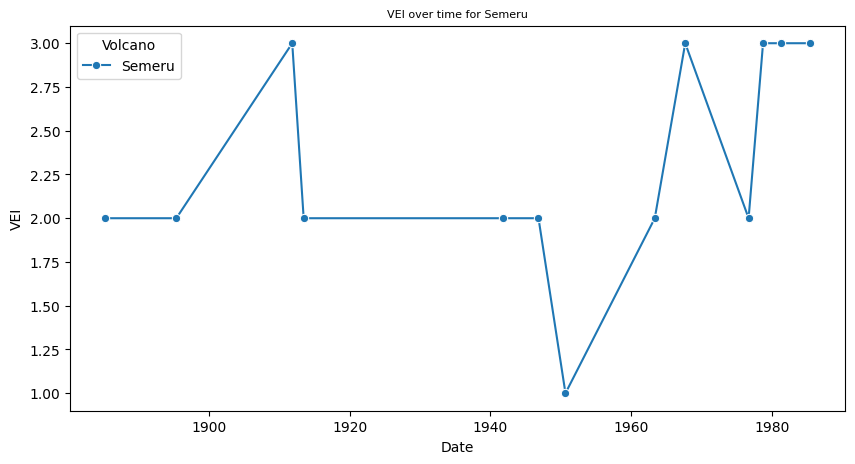

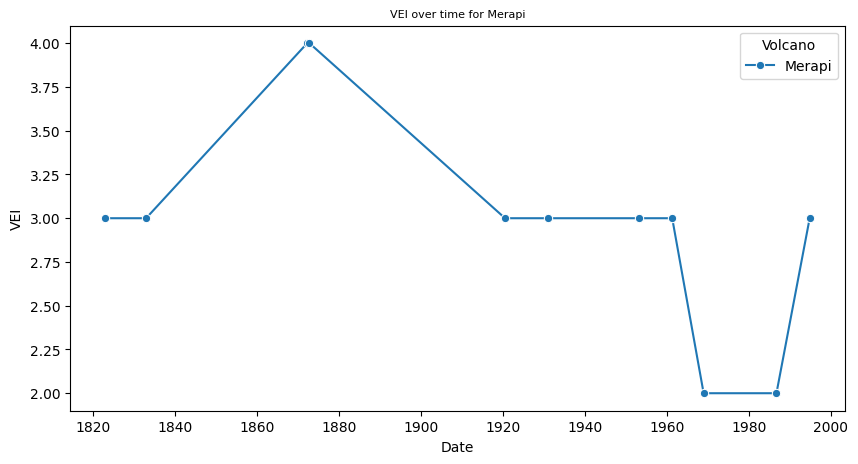

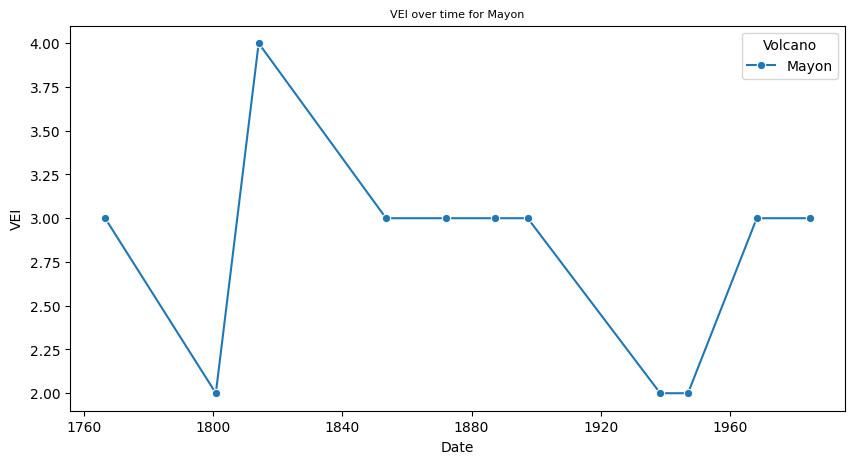

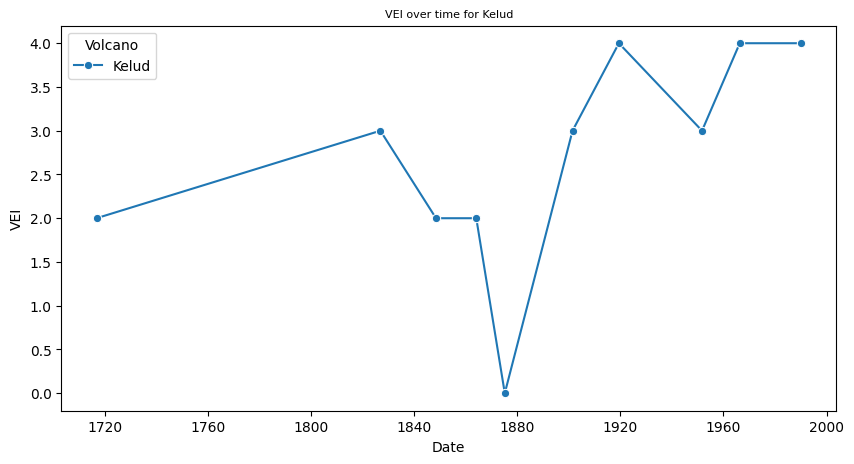

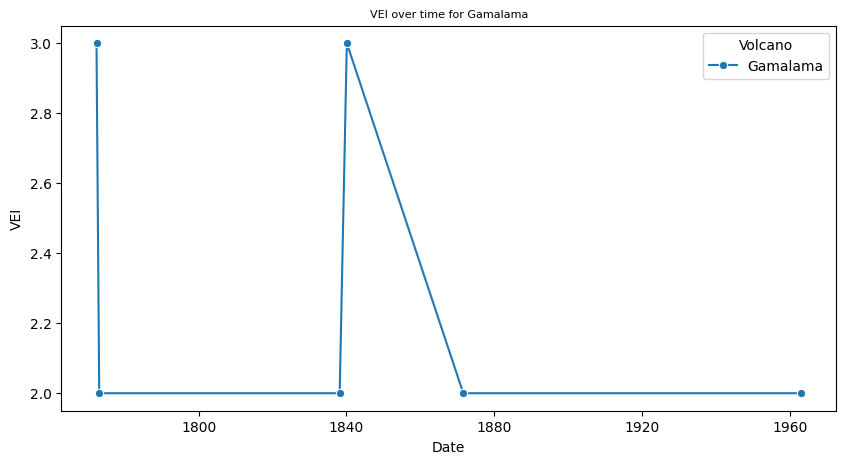

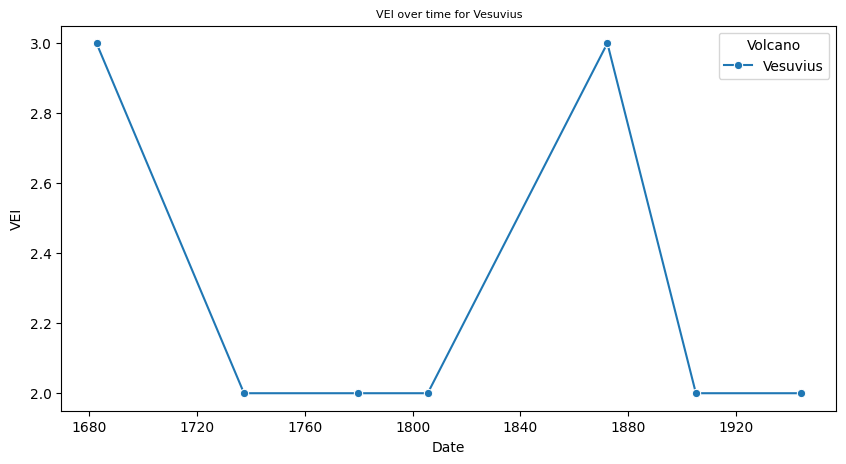

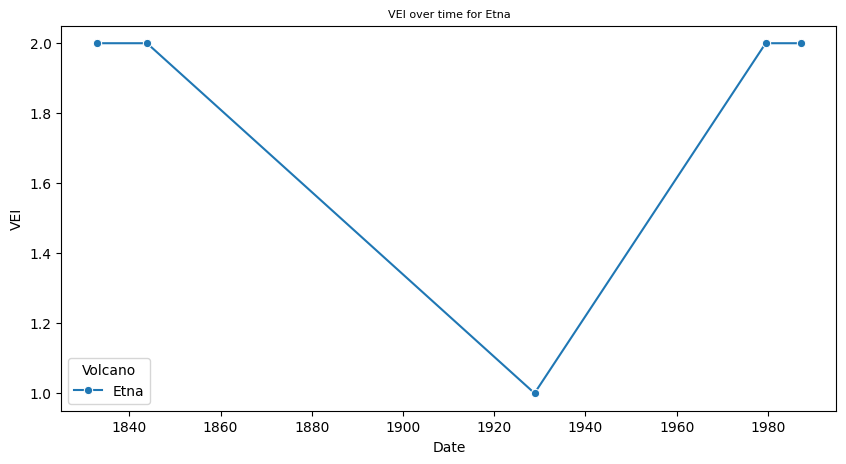

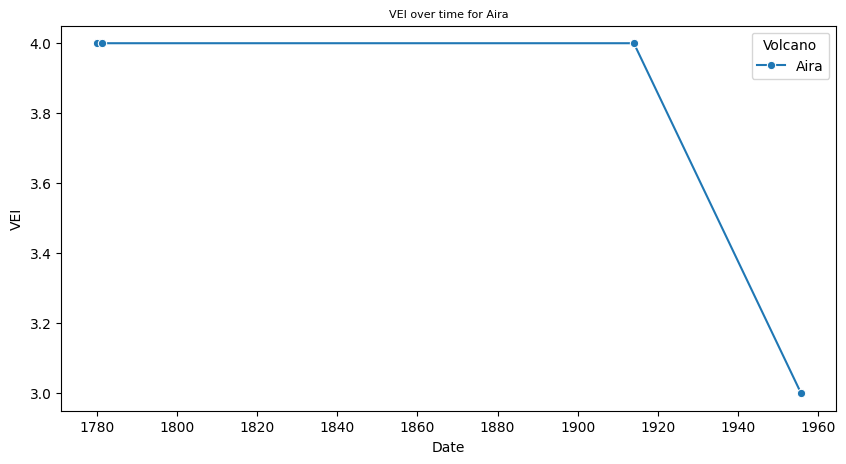

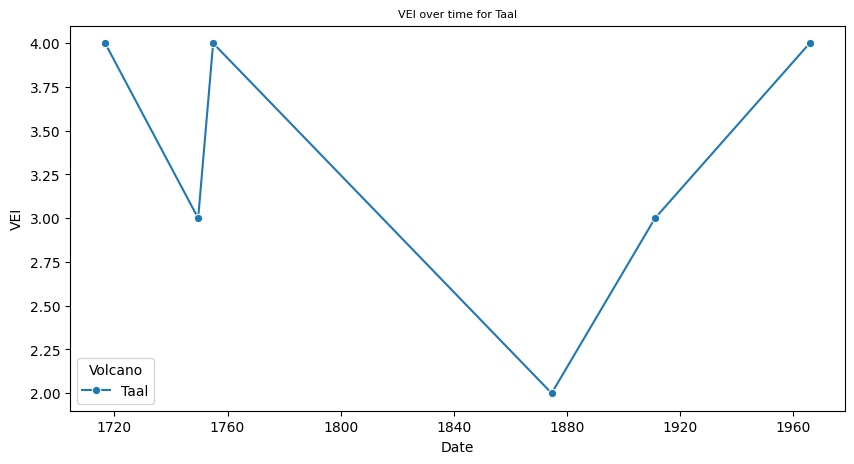

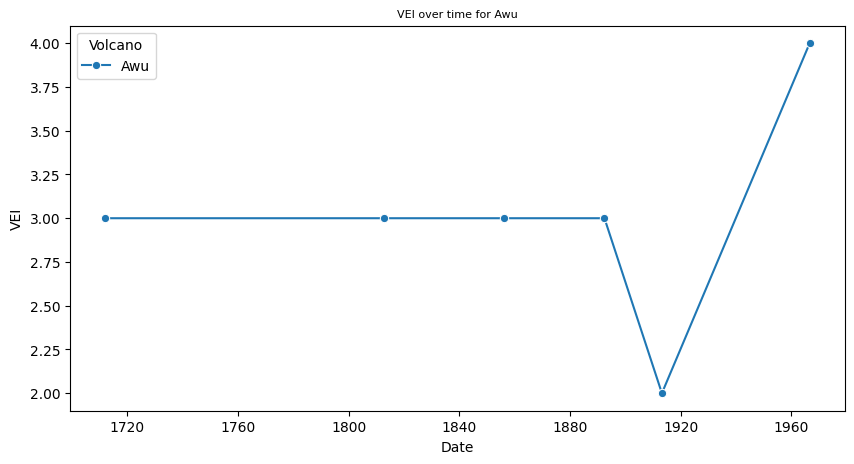

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
volcano_count = new_df['name'].value_counts()
more_than_3 = volcano_count[volcano_count > 3].index
for volcano in more_than_3:
    volcano_data = new_df[new_df['name'] == volcano]
    volcano_sort = volcano_data.sort_values('date')
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=volcano_sort, x='date', y='vei', marker='o', label=volcano)
    plt.title(f'VEI over time for {volcano}', fontsize=8)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel('VEI', fontsize=10)
    plt.legend(title='Volcano', fontsize=10)
    plt.show()

In [29]:
# Sample dataset
input_data = {
    'account' : [383080, 383080, 383080, 412290, 412290, 412290, 412290, 412290, 218895, 218895, 218895, 218895],
    'order' : [10001, 10001, 10001, 10005, 10005, 10005, 10005, 10005, 10006, 10006, 10006, 10006],
    'ext price' : [235.83, 232.32, 107.97, 2679.36, 286.02, 832.95, 3472.04, 915.12, 3061.12, 518.65, 216.9, -72.18]
}
# DataFrame
df = pd.DataFrame(input_data)
# Displays Dataframe
df.style.format({'ext price' : '{:.2f}'}).hide(axis='index')

account,order,ext price
383080,10001,235.83
383080,10001,232.32
383080,10001,107.97
412290,10005,2679.36
412290,10005,286.02
412290,10005,832.95
412290,10005,3472.04
412290,10005,915.12
218895,10006,3061.12
218895,10006,518.65


In [30]:
# Grouping by 'order'
group = df.groupby('order')
group
print("\nIntermediate Grouped Data (Before Aggregation):")
for grouping, order in group:
    display(order[['order', 'ext price']].style.format({'ext price' : '{:.2f}'}).hide(axis='index'))
    print()


Intermediate Grouped Data (Before Aggregation):


order,ext price
10001,235.83
10001,232.32
10001,107.97


order,ext price
10005,2679.36
10005,286.02
10005,832.95
10005,3472.04
10005,915.12


order,ext price
10006,3061.12
10006,518.65
10006,216.90
10006,-72.18


In [31]:
# Sum of 'ext_price' for each 'order'
aggregated_result = df.groupby('order')['ext price'].sum().reset_index()
# Aggregated result after re-grouping
print("\nAggregated Data (Sum of 'ext_price' per 'order'):")
for index, row in aggregated_result.iterrows():
    temp = pd.DataFrame([row])
    display(temp[['order', 'ext price']].style.format({'order' : '{:.0f}', 'ext price' : '{:.2f}'}).hide(axis='index'))
    print()


Aggregated Data (Sum of 'ext_price' per 'order'):


order,ext price
10001,576.12


order,ext price
10005,8185.49


order,ext price
10006,3724.49


In [32]:
# Reset index to combine result into a single DataFrame
final_result = aggregated_result.reset_index()
# Renaming columns
final_result = final_result.drop(columns=['index'])
final_result.columns = ['order', 'Order_Total']
# Final result
print("\nFinal Combined Result (Order and Total 'ext_price'):")
temp = pd.DataFrame(final_result)
display(temp.style.format({'Order_Total' : '{:.2f}'}).hide(axis='index'))


Final Combined Result (Order and Total 'ext_price'):


order,Order_Total
10001,576.12
10005,8185.49
10006,3724.49
